In [2]:
import pickle
import torch
import numpy as np
import pandas as pd
!pip install gpytorch
import gpytorch
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import ast

DEPRECATION: Loading egg at /Users/aditikhandelia/anaconda3/lib/python3.11/site-packages/mask_rcnn-2.1-py3.11.egg is deprecated. pip 23.3 will enforce this behaviour change. A possible replacement is to use pip for package installation..
  Obtaining dependency information for gpytorch from https://files.pythonhosted.org/packages/0e/58/ac756b7c9b7daec0382d7c8e0b2c70819df227826edd8aa5bce115470d5a/gpytorch-1.14-py3-none-any.whl.metadata
  Obtaining dependency information for jaxtyping from https://files.pythonhosted.org/packages/c9/b9/281e10e2d967ea5e481683eaec99f55ac5a61085ee60551c36942ef32bef/jaxtyping-0.3.2-py3-none-any.whl.metadata
  Obtaining dependency information for linear-operator>=0.6 from https://files.pythonhosted.org/packages/ed/c7/8a27fd8e182c611d4bf0aa9f0ea9046a7c843901d0f06c8cdcb599840a38/linear_operator-0.6-py3-none-any.whl.metadata
  Obtaining dependency information for wadler-lindig>=0.1.3 from https://files.pythonhosted.org/packages/f9/4e/ef53ee4a6bf563a7c0a33682d6fef7

In [ ]:
def load_tensors_batched(filepath):
    tensors = []
    with open(filepath) as f:
        lines = f.readlines()
        for i in range(1, len(lines), 3):
            arr = ast.literal_eval(lines[i].strip())
            t   = torch.tensor(arr)    
            tensors.append(t) 
    return torch.cat(tensors, dim=0)

tenors = load_tensors_batched("tensors_bart.txt")

In [28]:
print(tenors.shape)

torch.Size([200, 6, 768])


In [29]:
class GPLVMModel(gpytorch.models.ApproximateGP):
    def __init__(self, inducing_points):
        variational_distribution = gpytorch.variational.CholeskyVariationalDistribution(inducing_points.size(0))
        variational_strategy = gpytorch.variational.VariationalStrategy(
            self, inducing_points, variational_distribution, learn_inducing_locations=True
        )
        super().__init__(variational_strategy)

        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.RBFKernel()
        )

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)
    
    
def train_gplvm(X, latent_dim=2, n_inducing=30, num_iter=300):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Use PCA to initialize latent space
    U, S, V = torch.pca_lowrank(X, q=latent_dim)
    Z_init = X @ V[:, :latent_dim]
    Z_init = Z_init.to(device)

    y = X[:, 0].to(device)  # Use 1st dimension of X as target

    inducing_points = Z_init[:n_inducing]

    model = GPLVMModel(inducing_points).to(device)
    likelihood = gpytorch.likelihoods.GaussianLikelihood().to(device)

    model.train()
    likelihood.train()

    optimizer = torch.optim.Adam([
        {'params': model.parameters()},
        {'params': likelihood.parameters()},
    ], lr=0.01)

    mll = gpytorch.mlls.VariationalELBO(likelihood, model, num_data=y.size(0))

    for i in range(num_iter):
        optimizer.zero_grad()
        output = model(Z_init)
        loss = -mll(output, y)
        loss.backward()
        if i % 50 == 0:
            print(f"Iter {i}: loss = {loss.item():.4f}")
        optimizer.step()

    return model, likelihood, Z_init, y


In [33]:
X_avg = tenors.mean(dim=1)

model, likelihood, Z, y = train_gplvm(
    X_avg,
    latent_dim=2,
    n_inducing=30,
    num_iter=600
)

Iter 0: loss = 1.9085
Iter 50: loss = 1.2625
Iter 100: loss = 1.0633
Iter 150: loss = 0.8862
Iter 200: loss = 0.7326
Iter 250: loss = 0.6223
Iter 300: loss = 0.5584
Iter 350: loss = 0.5380
Iter 400: loss = 0.5321
Iter 450: loss = 0.5289
Iter 500: loss = 0.5248
Iter 550: loss = 0.5209


In [34]:
def plot_latent_space(Z, y):
    Z = Z.detach().cpu().numpy()
    y = y.detach().cpu().numpy()

    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(Z[:, 0], Z[:, 1], c=y, cmap='viridis', s=40, edgecolor='k')
    plt.colorbar(scatter, label='Target y')
    plt.title("GPLVM Latent Space (colored by y)")
    plt.xlabel("Latent dimension 1")
    plt.ylabel("Latent dimension 2")
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
    
def plot_gp_prediction_surface(model, likelihood, Z):
    model.eval()
    likelihood.eval()

    Z = Z.detach().cpu()
    x_min, x_max = Z[:, 0].min() - 0.5, Z[:, 0].max() + 0.5
    y_min, y_max = Z[:, 1].min() - 0.5, Z[:, 1].max() + 0.5

    # Create meshgrid
    xx, yy = torch.meshgrid(
        torch.linspace(x_min, x_max, 100),
        torch.linspace(y_min, y_max, 100),
        indexing='ij'
    )
    grid = torch.stack([xx.flatten(), yy.flatten()], dim=-1).to(Z.device)

    with torch.no_grad():
        preds = likelihood(model(grid))
        mean = preds.mean.cpu().numpy().reshape(xx.shape)

    # Plot
    plt.figure(figsize=(8, 6))
    contour = plt.contourf(xx.numpy(), yy.numpy(), mean, levels=100, cmap="viridis")
    plt.scatter(Z[:, 0].cpu(), Z[:, 1].cpu(), c='red', s=10, alpha=0.6, label="Training Points")
    plt.colorbar(contour, label='Predicted mean')
    plt.title("GP Predictive Mean Over Latent Space")
    plt.xlabel("Latent dimension 1")
    plt.ylabel("Latent dimension 2")
    plt.legend()
    plt.tight_layout()
    plt.show()

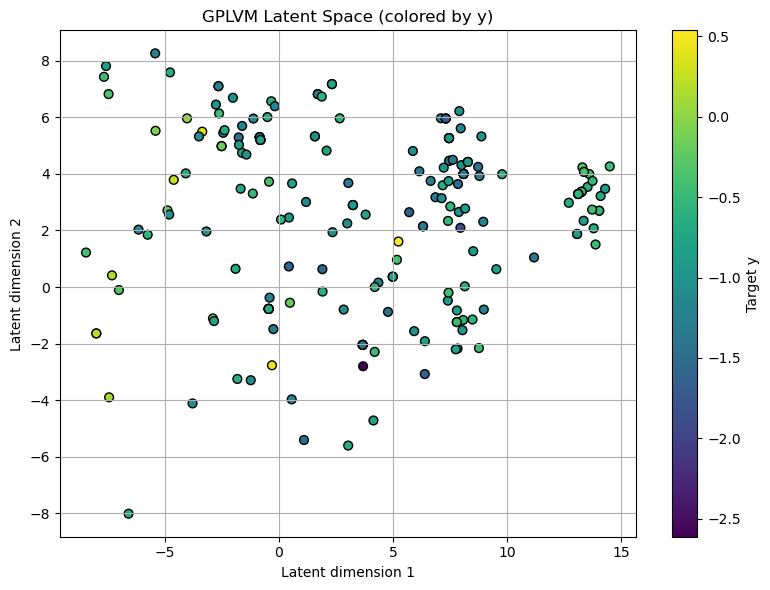

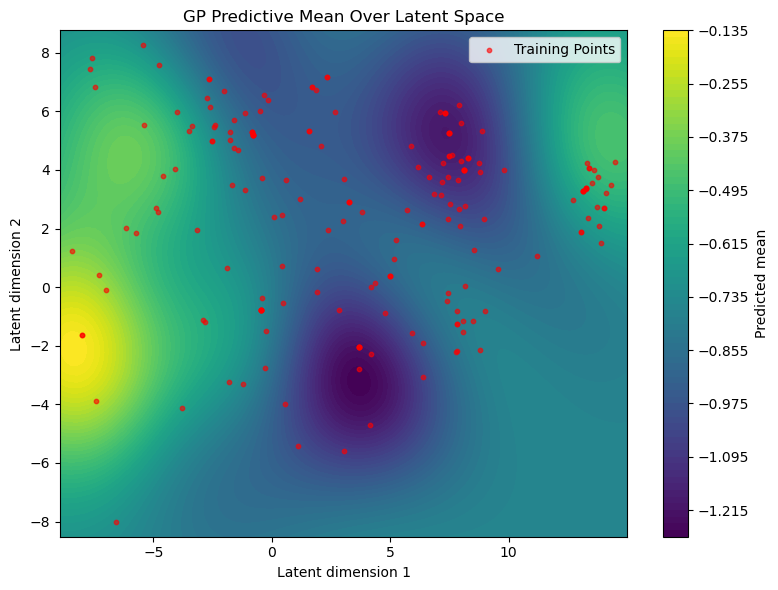

In [35]:
plot_latent_space(Z, y)
plot_gp_prediction_surface(model, likelihood, Z)

In [11]:
tenors = load_tensors_from_file("tensors.txt")

In [12]:
class GPLVMModel(gpytorch.models.ApproximateGP):
    def __init__(self, inducing_points):
        variational_distribution = gpytorch.variational.CholeskyVariationalDistribution(inducing_points.size(0))
        variational_strategy = gpytorch.variational.VariationalStrategy(
            self, inducing_points, variational_distribution, learn_inducing_locations=True
        )
        super().__init__(variational_strategy)

        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.RBFKernel()
        )

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)
    
    
def train_gplvm(X, latent_dim=2, n_inducing=30, num_iter=300):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Use PCA to initialize latent space
    U, S, V = torch.pca_lowrank(X, q=latent_dim)
    Z_init = X @ V[:, :latent_dim]
    Z_init = Z_init.to(device)

    y = X[:, 0].to(device)  # Use 1st dimension of X as target

    inducing_points = Z_init[:n_inducing]

    model = GPLVMModel(inducing_points).to(device)
    likelihood = gpytorch.likelihoods.GaussianLikelihood().to(device)

    model.train()
    likelihood.train()

    optimizer = torch.optim.Adam([
        {'params': model.parameters()},
        {'params': likelihood.parameters()},
    ], lr=0.01)

    mll = gpytorch.mlls.VariationalELBO(likelihood, model, num_data=y.size(0))

    for i in range(num_iter):
        optimizer.zero_grad()
        output = model(Z_init)
        loss = -mll(output, y)
        loss.backward()
        if i % 50 == 0:
            print(f"Iter {i}: loss = {loss.item():.4f}")
        optimizer.step()

    return model, likelihood, Z_init, y


In [13]:
model, likelihood, Z, y = train_gplvm(tenors, latent_dim=2, n_inducing=30, num_iter=600)

Iter 0: loss = 1.5830
Iter 50: loss = 1.0544
Iter 100: loss = 0.8379
Iter 150: loss = 0.7138
Iter 200: loss = 0.6725
Iter 250: loss = 0.6642
Iter 300: loss = 0.6612
Iter 350: loss = 0.6592
Iter 400: loss = 0.6576
Iter 450: loss = 0.6563
Iter 500: loss = 0.6551
Iter 550: loss = 0.6540


In [14]:
def plot_latent_space(Z, y):
    Z = Z.detach().cpu().numpy()
    y = y.detach().cpu().numpy()

    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(Z[:, 0], Z[:, 1], c=y, cmap='viridis', s=40, edgecolor='k')
    plt.colorbar(scatter, label='Target y')
    plt.title("GPLVM Latent Space (colored by y)")
    plt.xlabel("Latent dimension 1")
    plt.ylabel("Latent dimension 2")
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
    
def plot_gp_prediction_surface(model, likelihood, Z):
    model.eval()
    likelihood.eval()

    Z = Z.detach().cpu()
    x_min, x_max = Z[:, 0].min() - 0.5, Z[:, 0].max() + 0.5
    y_min, y_max = Z[:, 1].min() - 0.5, Z[:, 1].max() + 0.5

    # Create meshgrid
    xx, yy = torch.meshgrid(
        torch.linspace(x_min, x_max, 100),
        torch.linspace(y_min, y_max, 100),
        indexing='ij'
    )
    grid = torch.stack([xx.flatten(), yy.flatten()], dim=-1).to(Z.device)

    with torch.no_grad():
        preds = likelihood(model(grid))
        mean = preds.mean.cpu().numpy().reshape(xx.shape)

    # Plot
    plt.figure(figsize=(8, 6))
    contour = plt.contourf(xx.numpy(), yy.numpy(), mean, levels=100, cmap="viridis")
    plt.scatter(Z[:, 0].cpu(), Z[:, 1].cpu(), c='red', s=10, alpha=0.6, label="Training Points")
    plt.colorbar(contour, label='Predicted mean')
    plt.title("GP Predictive Mean Over Latent Space")
    plt.xlabel("Latent dimension 1")
    plt.ylabel("Latent dimension 2")
    plt.legend()
    plt.tight_layout()
    plt.show()

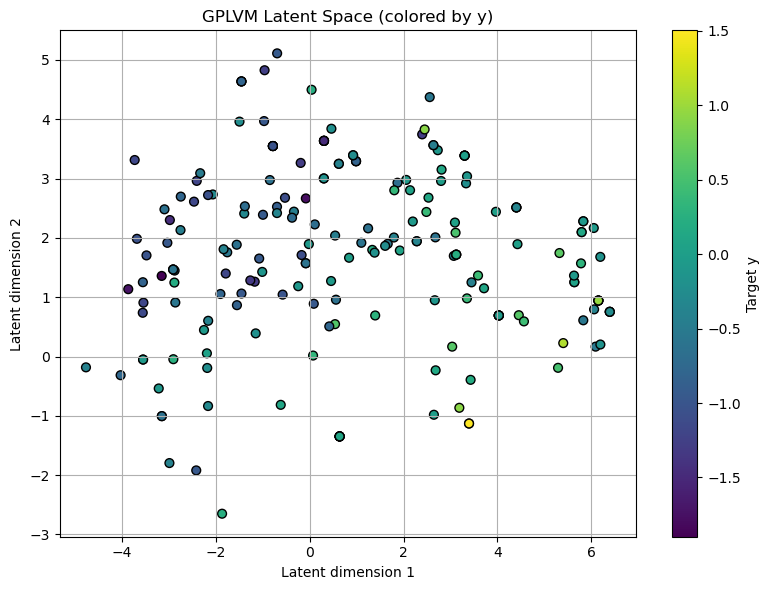

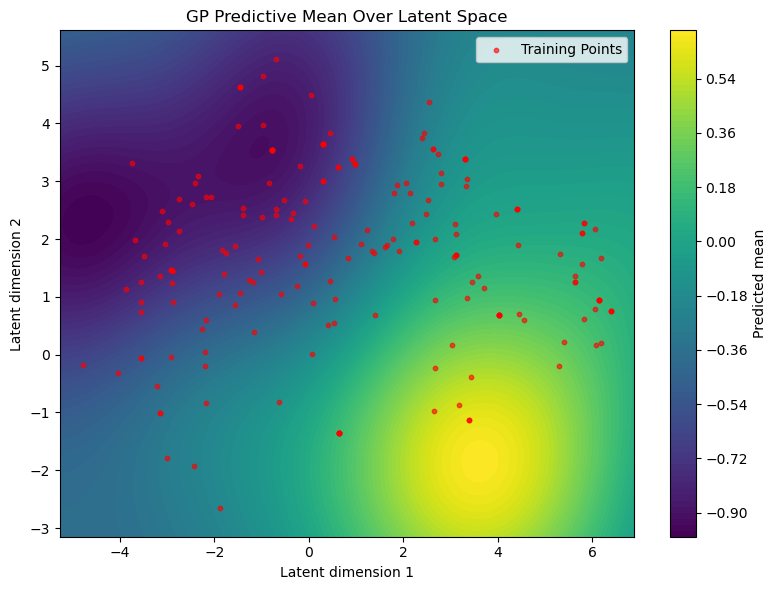

In [15]:
plot_latent_space(Z, y)
plot_gp_prediction_surface(model, likelihood, Z)